In [1]:
# cifar10 - 총 10개의 클래스로 구성된 6만장 칼라 이미지 데이터셋(5만 : train, 1만 : test)
# class_names = [
#     'airplane',
#     'automobile',
#     'bird',
#     'cat',
#     'deer',
#     'dog',
#     'frog',
#     'horse',
#     'ship',
#     'truck'
# ]

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10


(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f'Train data shape: {x_train.shape}, Train labels shape: {y_train.shape}')
# Train data shape: (50000, 32, 32, 3), Train labels shape: (50000, 1)
print(x_train[0])
print(y_train[0])   # [6] -> 6번 클래스 : frog

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Train data shape: (50000, 32, 32, 3), Train labels shape: (50000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


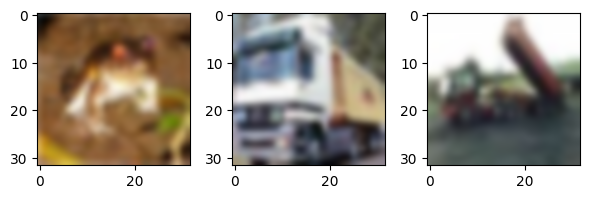

In [2]:
# 시각화 : x_train[0] ~ x_train[2] 까지 3장
plt.figure(figsize=(6, 2))
plt.subplot(1, 3, 1)
plt.imshow(x_train[0], interpolation='bicubic')
plt.subplot(1, 3, 2)
plt.imshow(x_train[1], interpolation='bicubic')
plt.subplot(1, 3, 3)
plt.imshow(x_train[2], interpolation='bicubic')
plt.tight_layout()
plt.show()

In [3]:
# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


# One-hot 인코딩
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)
print(y_train[0])   # [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.] -> 6번 클래스 : frog

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [4]:
# model
# 실습 1 : Sequential API - CNN 없는 모델
model_nocnn = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

print(model_nocnn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
# 실습 1-1 : Functional API - CNN 없는 모델
input_layer = Input(shape=(32, 32, 3))
x = Flatten()(input_layer)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
output_layer = Dense(NUM_CLASSES, activation='softmax')(x)

model_nocnn_func = Model(inputs=input_layer, outputs=output_layer)
print(model_nocnn_func.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# compile / fit
opti = Adam(learning_rate=0.001)
model_nocnn_func.compile(
    optimizer=opti,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_nocnn_func.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=2
)

print(f'test acc : {model_nocnn_func.evaluate(x_test, y_test, verbose=0, batch_size=128)[1]:.4f}')
print(f'test loss : {model_nocnn_func.evaluate(x_test, y_test, verbose=0, batch_size=128)[0]:.4f}')

# CNN을 사용하지 않았기 때문에 낮은 성능이 나옴. CNN을 사용한 모델과 비교해보자.

Epoch 1/20
391/391 - 4s - 10ms/step - accuracy: 0.3153 - loss: 1.9045
Epoch 2/20
391/391 - 1s - 3ms/step - accuracy: 0.3952 - loss: 1.6970
Epoch 3/20
391/391 - 2s - 4ms/step - accuracy: 0.4261 - loss: 1.6152
Epoch 4/20
391/391 - 1s - 4ms/step - accuracy: 0.4452 - loss: 1.5563
Epoch 5/20
391/391 - 2s - 6ms/step - accuracy: 0.4599 - loss: 1.5149
Epoch 6/20
391/391 - 1s - 3ms/step - accuracy: 0.4688 - loss: 1.4867
Epoch 7/20
391/391 - 1s - 3ms/step - accuracy: 0.4831 - loss: 1.4555
Epoch 8/20
391/391 - 1s - 3ms/step - accuracy: 0.4893 - loss: 1.4289
Epoch 9/20
391/391 - 1s - 3ms/step - accuracy: 0.5011 - loss: 1.4086
Epoch 10/20
391/391 - 1s - 3ms/step - accuracy: 0.5095 - loss: 1.3819
Epoch 11/20
391/391 - 1s - 3ms/step - accuracy: 0.5158 - loss: 1.3626
Epoch 12/20
391/391 - 2s - 4ms/step - accuracy: 0.5201 - loss: 1.3503
Epoch 13/20
391/391 - 1s - 4ms/step - accuracy: 0.5272 - loss: 1.3301
Epoch 14/20
391/391 - 1s - 3ms/step - accuracy: 0.5293 - loss: 1.3156
Epoch 15/20
391/391 - 1s - 3

In [7]:
CLASSES = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
])


# 에측
pred = model_nocnn_func.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)]   # 0 : 열 기준, 1 : 행 기준
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]   # -1 : 행 단위 뒤에서 부터 처리


print('예측값 : ', pred)
print('실제값 : ', actual)
print('분류 실패 수 : ', (pred != actual).sum())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
예측값 :  ['cat' 'ship' 'ship' 'horse' 'deer' 'frog' 'cat' 'frog' 'dog' 'automobile']
실제값 :  ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 :  4


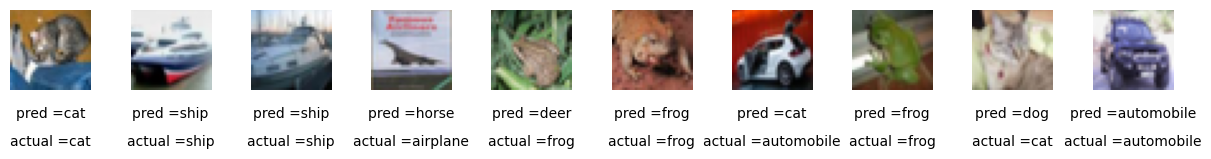

In [8]:
# 시각화
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.5, wspace=0.5) # → subplot 사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i+1)
    ax.axis('off')
    ax.imshow(img)

    # transform=ax.transAxes : 축 좌표계로 텍스트 위치 지정, 이미지 픽셀 대신에 sbplot영역 기준 (0.5 → 중앙)
    ax.text(0.5, -0.35, 'pred =' + str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual =' + str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)

plt.show()